# Create region segmentation

In [2]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from natsort import natsorted
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set IO path
base_path = '/home/jiahao/wanglab/Data/Analyzed/2024-12-02-Mingrui-SCZ/'
expr_path = os.path.join(base_path, 'expr')
fig_path = os.path.join(base_path, 'figures')
output_path = os.path.join(base_path, 'output')
os.makedirs(output_path, exist_ok=True)

sc.settings.figdir = fig_path
input_path = os.path.join(expr_path, 'tissue region identification')

## Input

In [4]:
adata = sc.read_h5ad(os.path.join(expr_path, '2025-04-11-finalized-ct-rgn.h5ad'))
adata

AnnData object with n_obs × n_vars = 538188 × 3447
    obs: 'sample', 'fov_id', 'volume', 'fov_x', 'fov_y', 'seg_label', 'global_x', 'global_y', 'sample_id', 'condition', 'protocol', 'unique_index', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'n_counts', 'replicate', 'coronal_position', 'genotype', 'protocol_replicate', 'genotype_protocol_replicate', 'leiden', 'orig_leiden', 'level_1', 'level_2', 'level_3', 'global_x_aligned', 'global_y_aligned', 'region_label'
    var: 'highly_variable', 'mean', 'std', 'max_counts'
    uns: 'level_1_color_dict', 'level_1_colors', 'level_1_order', 'level_2_color_dict', 'level_2_colors', 'level_2_order', 'level_3_color_dict', 'level_3_colors', 'level_3_order', 'region_label_color_dict', 'region_label_order'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'
    varm: 'PCs'
  

In [14]:
adata.obs['region_codes'] = adata.obs['region_label'].cat.codes + 1
adata.obs['region_codes'].unique()

array([ 1,  2,  3,  4, 21, 22, 14, 15, 23,  7,  8, 17, 16, 20, 18, 13, 10,
       12, 11, 19,  5,  6,  9], dtype=int8)

## Grid Quantification

In [18]:
from skimage.util import regular_seeds, img_as_ubyte
from skimage.segmentation import watershed
from skimage.measure import regionprops
from natsort import natsorted
import tifffile

In [19]:
reads_path = os.path.join(expr_path, 'reads assignment')
quant_output_path = os.path.join(output_path, 'grid_quantification')
os.makedirs(quant_output_path, exist_ok=True)

In [24]:
grid_interval = 30 # micron
scaling_factor = 0.25 

gdata_list = []
for current_sample in natsorted(adata.obs['sample_id'].unique()):
# for current_sample in natsorted(adata.obs['sample_id'].unique())[:1]:
    print(current_sample)
    sample_reads_df = pd.read_csv(os.path.join(reads_path, f'{current_sample}_reads_assignment.csv'), index_col=0)
    sample_shape = (sample_reads_df.global_x.max(), sample_reads_df.global_y.max())

    # only use bg reads 
    sample_reads_df = sample_reads_df[sample_reads_df['seg_label'] == 0]

    # # create a grid of seeds
    # read_dim = (sample_shape[0] * 0.14, sample_shape[1] * 0.14)
    # read_area = read_dim[0] * read_dim[1]
    # grid_area = grid_interval**2
    # n_seeds = int(read_area / grid_area)

    # # create a grid segmentation
    # scaled_dim = (round(sample_shape[0] * scaling_factor) + 1, round(sample_shape[1] * scaling_factor) + 1)
    # img = np.ones(scaled_dim, dtype=int)
    # img = img_as_ubyte(img * 255)
    # seeds = regular_seeds(scaled_dim, n_seeds)
    # grid_seg = watershed(img, seeds, compactness=0.01)
    # tifffile.imsave(os.path.join(quant_output_path, f"{current_sample}_grid_{grid_interval}.tif"), grid_seg.astype(np.uint16))
    
    # load the grid segmentation
    grid_seg = tifffile.imread(os.path.join(quant_output_path, f"{current_sample}_grid_{grid_interval}.tif"))
    grid_seg = grid_seg.astype(np.uint16)


    # assign reads to grid
    points = sample_reads_df.loc[:, ["global_x", "global_y"]].values
    points = points * scaling_factor
    points = points.astype(int)
    bases = sample_reads_df['gene'].values
    reads_assignment = grid_seg[points[:, 0], points[:, 1]]
    sample_reads_df['grid_label'] = reads_assignment

    grid_locs = []
    total_grids = len(np.unique(grid_seg))
    areas = []
    seg_labels = []

    # Load genes.csv
    genes_df = pd.read_csv(os.path.join(base_path, "documents", "genes.csv"), header=None)
    genes_df.columns = ['gene', 'barcode']

    genes = genes_df['gene'].values
    gene_seq_to_index = {}  # map from sequence to index into matrix

    for i, k in enumerate(genes):
        gene_seq_to_index[k] = i

    grid_by_gene = np.zeros((total_grids, len(genes)))

    print('Iterate grid...')
    for i, region in enumerate(tqdm(regionprops(grid_seg))):
        areas.append(region.area)
        grid_locs.append(region.centroid)
        seg_labels.append(region.label)

        assigned_reads = bases[np.argwhere(reads_assignment == region.label).flatten()]
        for j in assigned_reads:
            if j in gene_seq_to_index:
                grid_by_gene[i, gene_seq_to_index[j]] += 1

    grid_by_gene_df = pd.DataFrame(grid_by_gene, columns=genes)

    grid_locs = np.array(grid_locs, dtype=int)

    # create a scanpy object
    gdata = ad.AnnData(grid_by_gene_df)
    gdata.var = pd.DataFrame(index=grid_by_gene_df.columns)
    gdata.obs = pd.DataFrame(index=grid_by_gene_df.index)

    # add annotation 
    gdata.obs['sample_id'] = current_sample
    gdata.obs['global_x_scaled'] = grid_locs[:, 0]
    gdata.obs['global_y_scaled'] = grid_locs[:, 1]
    
    gdata_list.append(gdata)

sample1
Iterate grid...


  0%|          | 0/19995 [00:00<?, ?it/s]

sample2
Iterate grid...


  0%|          | 0/16698 [00:00<?, ?it/s]

sample3
Iterate grid...


...

  0%|          | 0/14577 [00:00<?, ?it/s]

sample23
Iterate grid...


  0%|          | 0/17787 [00:00<?, ?it/s]

sample24
Iterate grid...


  0%|          | 0/14641 [00:00<?, ?it/s]

In [25]:
cdata = ad.concat(gdata_list)
cdata.obs['condition'] = cdata.obs.sample_id.map(adata.obs.set_index('sample_id')['condition'].to_dict())
cdata.obs['protocol'] = cdata.obs.sample_id.map(adata.obs.set_index('sample_id')['protocol'].to_dict())
cdata.obs['replicate'] = cdata.obs.sample_id.map(adata.obs.set_index('sample_id')['replicate'].to_dict())
cdata.obs['coronal_position'] = cdata.obs.sample_id.map(adata.obs.set_index('sample_id')['coronal_position'].to_dict())
cdata.obs.index = cdata.obs.sample_id.astype(str) + '_' + cdata.obs.index.astype(str)

In [29]:
cdata.obs

,sample_id,global_x_scaled,global_y_scaled,condition,protocol,replicate,coronal_position
sample1_0,sample1,26,26,WT,RIBO,rep1,PFC
sample1_1,sample1,26,80,WT,RIBO,rep1,PFC
sample1_2,sample1,26,134,WT,RIBO,rep1,PFC
sample1_3,sample1,26,188,WT,RIBO,rep1,PFC
sample1_4,sample1,26,242,WT,RIBO,rep1,PFC
...,...,...,...,...,...,...,...
sample24_14636,sample24,6493,6290,HET,STAR,rep2,PFC
sample24_14637,sample24,6493,6344,HET,STAR,rep2,PFC
sample24_14638,sample24,6493,6398,HET,STAR,rep2,PFC
sample24_14639,sample24,6493,6452,HET,STAR,rep2,PFC


In [30]:
from tifffile import imread

cdata.obs['region_codes'] = '0'
for current_sample in tqdm(natsorted(cdata.obs['sample_id'].unique())):

    # load region segmentation
    seg_path = os.path.join(output_path, 'spin_mask_new', current_sample)
    current_seg = imread(os.path.join(seg_path, 'mask.tif'))

    current_obs = cdata.obs.loc[cdata.obs['sample_id'] == current_sample, ].copy()
    
    # keep the reads within region
    current_obs = current_obs.loc[(current_obs['global_x_scaled'] >= 0) & (current_obs['global_x_scaled'] < current_seg.shape[1]) & (current_obs['global_y_scaled'] >= 0) & (current_obs['global_y_scaled'] < current_seg.shape[0]), ]
    current_obs['region_codes'] = current_seg[current_obs['global_y_scaled'], current_obs['global_x_scaled']]
    current_obs['region_codes'] = current_obs['region_codes'].astype(int)
    current_obs['region_codes'] = current_obs['region_codes'].astype(str)

    cdata.obs.loc[current_obs.index, 'region_codes'] = current_obs['region_codes'].values


  0%|          | 0/24 [00:00<?, ?it/s]

In [39]:
region_dict = adata.obs.set_index('region_codes')['region_label'].to_dict()
region_dict[0] = 'NA'

cdata.obs['region_codes'] = cdata.obs['region_codes'].astype(int)
cdata.obs['region_label'] = cdata.obs['region_codes'].map(region_dict)

In [48]:
cdata.obs['region_label'] = cdata.obs['region_label'].astype('category')
cdata.obs['region_label'] = cdata.obs['region_label'].cat.reorder_categories(list(adata.obs['region_label'].cat.categories) + ['NA'])

In [54]:
cdata.write_h5ad(os.path.join(quant_output_path, '2025-05-12-all-sample-grid-quantification.h5ad'))

Text(0.5, 1.0, 'sample24')

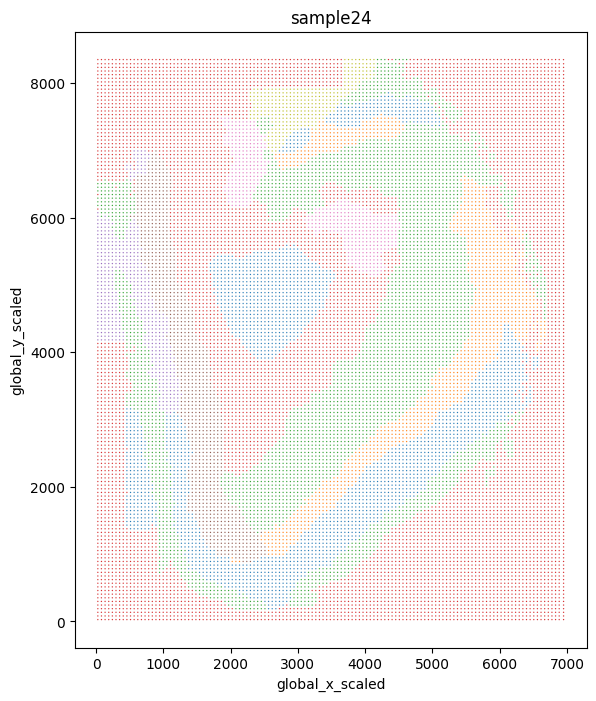

In [52]:
# plot with same aspect ratio
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')
sns.scatterplot(data=cdata.obs.loc[cdata.obs['sample_id'] == 'sample1'], x='global_x_scaled', y='global_y_scaled', hue='region_label', alpha=1, s=1, palette='tab10', legend=None, ax=ax)
plt.title(current_sample)
# plt.savefig(os.path.join(fig_path, f'{current_sample}_grid_segmentation.png'), dpi=300)